# 📊 Complete Data Science EDA & Feature Engineering Notebook
### CSV + JSON + SQL | Pastel-Themed Visualizations | Full Pipeline

## 1. 📦 Imports & Setup

In [41]:
#import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json, sqlite3, warnings, os
from scipy import stats
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler,
    RobustScaler, MaxAbsScaler, PowerTransformer, FunctionTransformer,
    OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# ── Pastel Theme ──
PASTEL = ["#FFB3BA","#FFDFBA","#FFFFBA","#BAFFC9","#BAE1FF",
          "#D4B8E0","#B8D4E0","#E0B8D4","#B8E0C8","#E0D4B8"]
BG     = "#FAFAFA"
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   "#CCCCCC",
    "axes.labelcolor":  "#444444",
    "xtick.color":      "#666666",
    "ytick.color":      "#666666",
    "text.color":       "#333333",
    "grid.color":       "#EEEEEE",
    "grid.linestyle":   "--",
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})
sns.set_palette(PASTEL)
print("✅ All imports successful. Pastel theme applied.")

✅ All imports successful. Pastel theme applied.


## 2. 📂 Data Loading — CSV, JSON & SQL

### 2a. Load CSV (Users)

In [42]:
# Load the dataset

users_df = pd.read_csv("users - users.csv.csv")
print("Shape:", users_df.shape)
print("Columns:", users_df.columns.tolist())
users_df.head(10)

Shape: (290, 6)
Columns: ['user_id', 'name', 'age', 'gender', 'city', 'registration_date']


,user_id,name,age,gender,city,registration_date
0,U0001,Vihaan Sharma,35,Other,Jaipur,9/8/2022
1,U0002,Sai Reddy,30,Other,Hyderabad,11/24/2023
2,U0003,Aarohi Gupta,37,Other,Indore,2/2/2022
3,U0004,Aarav Gupta,44,Male,Kolkata,6/2/2023
4,U0005,Sara Sharma,30,Other,Chennai,1/4/2024
5,U0006,Aarohi Mukherjee,30,Male,Thane,8/27/2023
6,U0007,Ishaan Sharma,44,Male,Indore,12/15/2022
7,U0008,Ishaan Reddy,38,Male,Lucknow,4/15/2022
8,U0009,Aditya Bose,28,Male,Kanpur,5/17/2024
9,U0010,Diya Kulkarni,36,Female,Delhi,1/18/2024


### 2b. Load JSON (Sales / Transactions)

In [43]:
# Load the sales dataset
with open("sales.json") as f:
    sales_data = json.load(f)

sales_df = pd.DataFrame(sales_data)
print("Shape:", sales_df.shape)
print("Columns:", sales_df.columns.tolist())
sales_df.head(10)

Shape: (1000, 6)
Columns: ['transaction_id', 'user_id', 'product_id', 'amount', 'payment_type', 'date']


,transaction_id,user_id,product_id,amount,payment_type,date
0,T000001,U0024,P015,67.67,Wallet,2023-02-12
1,T000002,U0196,P044,76.44,UPI,2023-03-24
2,T000003,U0196,P049,104.57,Debit Card,2025-08-21
3,T000004,U0133,P042,102.75,Net Banking,2024-07-23
4,T000005,U0047,P038,23.89,Net Banking,2025-10-04
5,T000006,U0024,P031,31.10,UPI,2025-04-16
6,T000007,U0086,P021,74.37,Wallet,2023-08-03
7,T000008,U0042,P022,74.31,Net Banking,2025-10-11
8,T000009,U0074,P043,74.37,Net Banking,2023-03-17
9,T000010,U0117,P006,550.95,UPI,2024-05-31


### 2c. Load SQL (Inventory via SQLite)

In [44]:
# Load the inventory dataset from SQL

sql_script = open("inventory.sql").read()
conn = sqlite3.connect(":memory:")
conn.executescript(sql_script)
inv_df = pd.read_sql("SELECT * FROM products", conn)
print("Shape:", inv_df.shape)
inv_df.head()

Shape: (50, 5)


,product_id,product_name,category,price,stock
0,P001,Product_001,Grocery,264.89,371
1,P002,Product_002,Grocery,605.91,150
2,P003,Product_003,Beauty,3027.98,127
3,P004,Product_004,Toys,2600.12,229
4,P005,Product_005,Books,1178.99,18


## 3. 🔍 Data Understanding — Info, Dtypes, Summary

In [45]:
# Display basic info for each DataFrame
# This code prints the structure and summary of each DataFrame (users_df, sales_df, inv_df) to understand their columns, data types, and non-null counts.
# It's a crucial step in EDA to get an overview of the datasets before diving deeper into analysis.
print("=" * 50)
print("USERS DataFrame Info")
print("=" * 50)
print(users_df.info())
print()
print("=" * 50)
print("SALES DataFrame Info")
print("=" * 50)
print(sales_df.info())
print()
print("=" * 50)
print("INVENTORY DataFrame Info")
print("=" * 50)
print(inv_df.info())

USERS DataFrame Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            290 non-null    object
 1   name               290 non-null    object
 2   age                290 non-null    int64 
 3   gender             290 non-null    object
 4   city               290 non-null    object
 5   registration_date  290 non-null    object
dtypes: int64(1), object(5)
memory usage: 13.7+ KB
None

SALES DataFrame Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1000 non-null   object 
 1   user_id         1000 non-null   object 
 2   product_id      1000 non-null   object 
 3   amount          1000 non-null   float64
 4   payment_type    1000 non-null   object 
 

### 3b. Descriptive Statistics

In [46]:
# Display descriptive statistics for each DataFrame

print("Users describe:")
display(users_df.describe(include="all"))
print()
print("Sales describe:")
display(sales_df.describe(include="all"))
print()
print("Inventory describe:")
display(inv_df.describe(include="all"))

Users describe:


,user_id,name,age,gender,city,registration_date
count,290,290,290.000000,290,290,290
unique,290,249,NaN,3,30,269
top,U0001,Vivaan Ghosh,NaN,Male,Ahmedabad,2/10/2022
freq,1,3,NaN,116,24,2
mean,NaN,NaN,30.762069,NaN,NaN,NaN
std,NaN,NaN,6.861099,NaN,NaN,NaN
min,NaN,NaN,18.000000,NaN,NaN,NaN
25%,NaN,NaN,25.000000,NaN,NaN,NaN
50%,NaN,NaN,31.000000,NaN,NaN,NaN
75%,NaN,NaN,35.000000,NaN,NaN,NaN



Sales describe:


,transaction_id,user_id,product_id,amount,payment_type,date
count,1000,1000,1000,1000.000000,1000,1000
unique,1000,200,50,NaN,6,636
top,T000001,U0117,P042,NaN,Wallet,2023-10-14
freq,1,13,31,NaN,180,7
mean,NaN,NaN,NaN,67.599040,NaN,NaN
std,NaN,NaN,NaN,45.411375,NaN,NaN
min,NaN,NaN,NaN,7.810000,NaN,NaN
25%,NaN,NaN,NaN,37.745000,NaN,NaN
50%,NaN,NaN,NaN,56.390000,NaN,NaN
75%,NaN,NaN,NaN,82.935000,NaN,NaN



Inventory describe:


,product_id,product_name,category,price,stock
count,50,50,50,50.000000,50.000000
unique,50,50,8,NaN,NaN
top,P001,Product_001,Books,NaN,NaN
freq,1,1,9,NaN,NaN
mean,NaN,NaN,NaN,2422.600600,225.720000
std,NaN,NaN,NaN,1282.179882,141.827581
min,NaN,NaN,NaN,128.310000,18.000000
25%,NaN,NaN,NaN,1456.655000,128.750000
50%,NaN,NaN,NaN,2449.910000,202.500000
75%,NaN,NaN,NaN,3401.080000,306.750000


## 4. 🔗 Merge Datasets

In [47]:
# Merge datasets to create a comprehensive DataFrame for analysis.

df = sales_df.merge(users_df, on="user_id", how="left")
df = df.merge(inv_df[[ "product_id","category","price","stock"]], on="product_id", how="left")
print("Merged shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Merged shape: (1000, 14)
Columns: ['transaction_id', 'user_id', 'product_id', 'amount', 'payment_type', 'date', 'name', 'age', 'gender', 'city', 'registration_date', 'category', 'price', 'stock']


,transaction_id,user_id,product_id,amount,payment_type,date,name,age,gender,city,registration_date,category,price,stock
0,T000001,U0024,P015,67.67,Wallet,2023-02-12,Aarohi Kapoor,20,Female,Patna,3/15/2023,Books,2286.25,251
1,T000002,U0196,P044,76.44,UPI,2023-03-24,Kabir Kulkarni,35,Other,Patna,8/1/2024,Beauty,1655.45,268
2,T000003,U0196,P049,104.57,Debit Card,2025-08-21,Kabir Kulkarni,35,Other,Patna,8/1/2024,Home,1701.17,159
3,T000004,U0133,P042,102.75,Net Banking,2024-07-23,Diya Singh,23,Female,Indore,7/6/2023,Home,4406.39,59
4,T000005,U0047,P038,23.89,Net Banking,2025-10-04,Anaya Gupta,28,Other,Kolkata,10/13/2022,Home,393.65,58


## 5. 📈 Univariate EDA

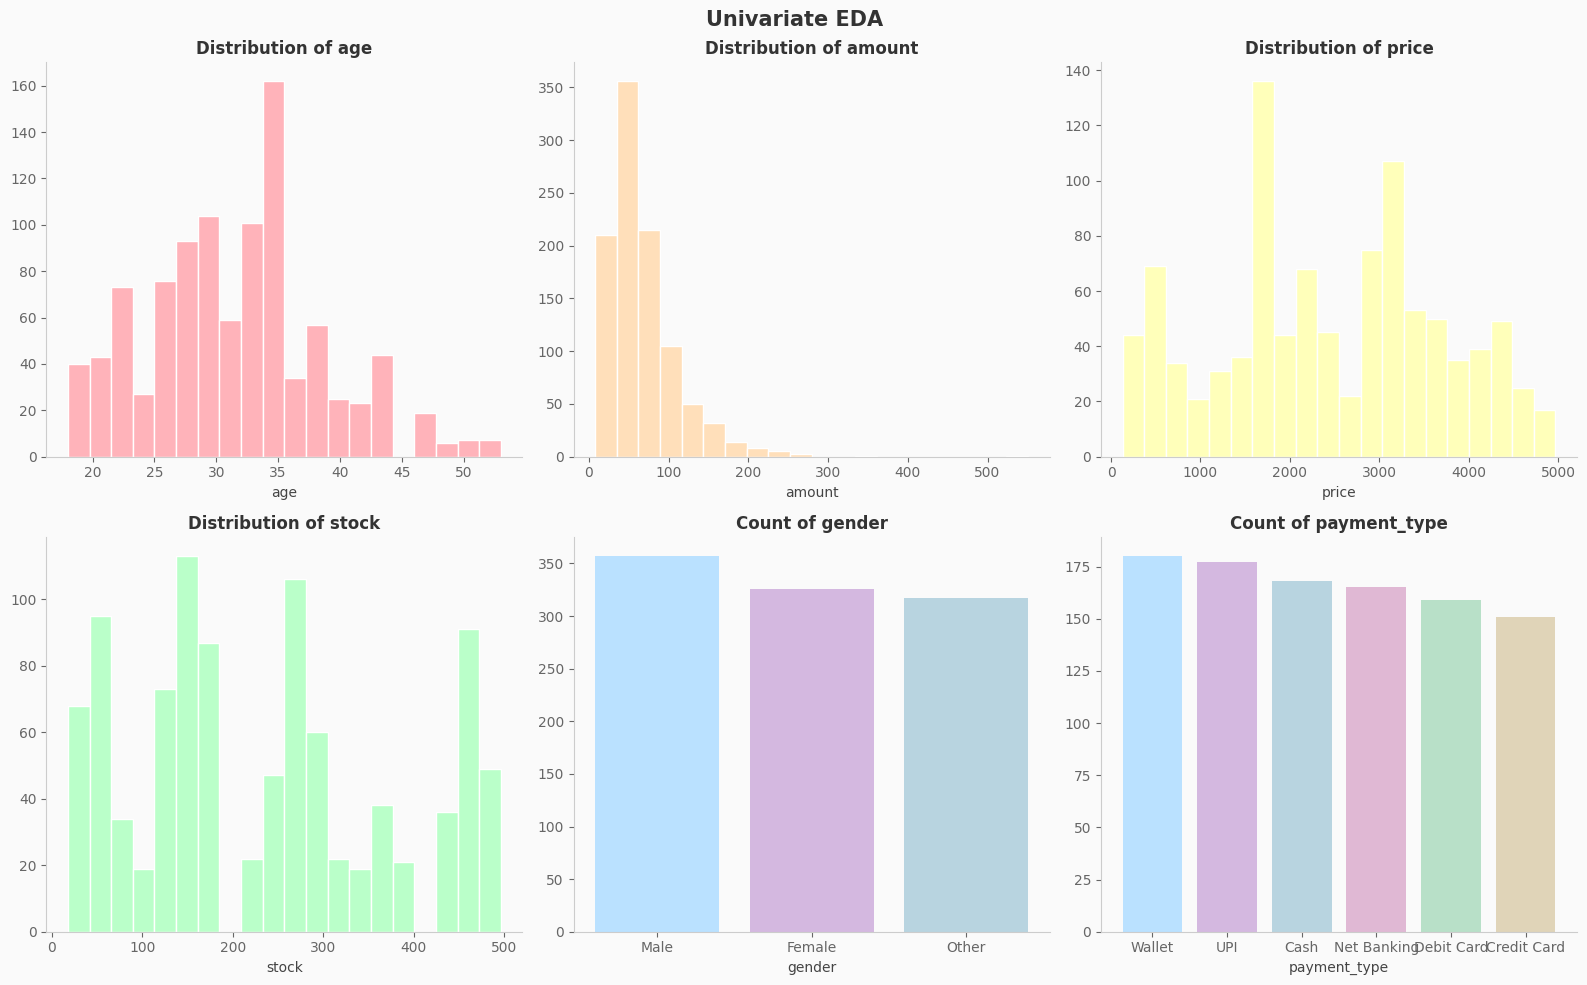

In [48]:
# Univariate EDA: Histograms for numeric and bar charts for categorical variables

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

num_cols = ["age", "amount", "price", "stock"]
cat_cols = ["gender", "payment_type", "category"]

# Numeric histograms
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=20, color=PASTEL[i], edgecolor="white")
    axes[i].set_title(f"Distribution of {col}", fontweight="bold")
    axes[i].set_xlabel(col)

# Categorical bar charts
for j, col in enumerate(cat_cols[:2]):
    vc = df[col].value_counts()
    axes[4+j].bar(vc.index, vc.values, color=PASTEL[4:4+len(vc)])
    axes[4+j].set_title(f"Count of {col}", fontweight="bold")
    axes[4+j].set_xlabel(col)

plt.suptitle("Univariate EDA", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_univariate.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. 🔄 Bivariate EDA

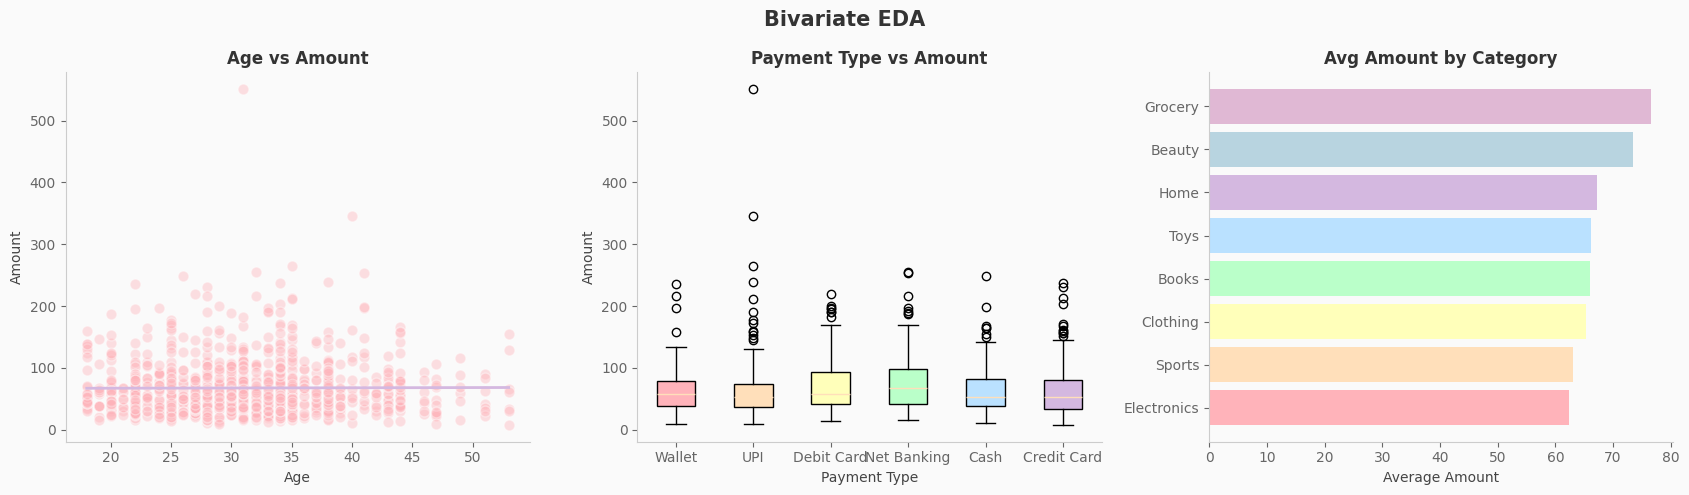

In [49]:
# Bivariate EDA: Scatter plots, boxplots, and bar charts to explore relationships between variables

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# amount vs age scatter
axes[0].scatter(df["age"], df["amount"], alpha=0.4, color=PASTEL[0], edgecolors="white", s=60)
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Amount")
axes[0].set_title("Age vs Amount", fontweight="bold")
m, b, r, p, _ = stats.linregress(df[["age","amount"]].dropna()["age"],
                                  df[["age","amount"]].dropna()["amount"])
x = np.linspace(df["age"].min(), df["age"].max(), 100)
axes[0].plot(x, m*x+b, color="#D4B8E0", linewidth=2)

# payment_type vs amount boxplot
grps = [df[df["payment_type"]==pt]["amount"].dropna() for pt in df["payment_type"].unique()]
bplot = axes[1].boxplot(grps, patch_artist=True, labels=df["payment_type"].unique())
for patch, c in zip(bplot["boxes"], PASTEL):
    patch.set_facecolor(c)
axes[1].set_title("Payment Type vs Amount", fontweight="bold")
axes[1].set_xlabel("Payment Type"); axes[1].set_ylabel("Amount")

# category vs avg price
cat_avg = df.groupby("category")["amount"].mean().sort_values()
axes[2].barh(cat_avg.index, cat_avg.values, color=PASTEL[:len(cat_avg)])
axes[2].set_title("Avg Amount by Category", fontweight="bold")
axes[2].set_xlabel("Average Amount")

plt.suptitle("Bivariate EDA", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_bivariate.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. 🌐 Multivariate EDA — Correlation & Pairplot

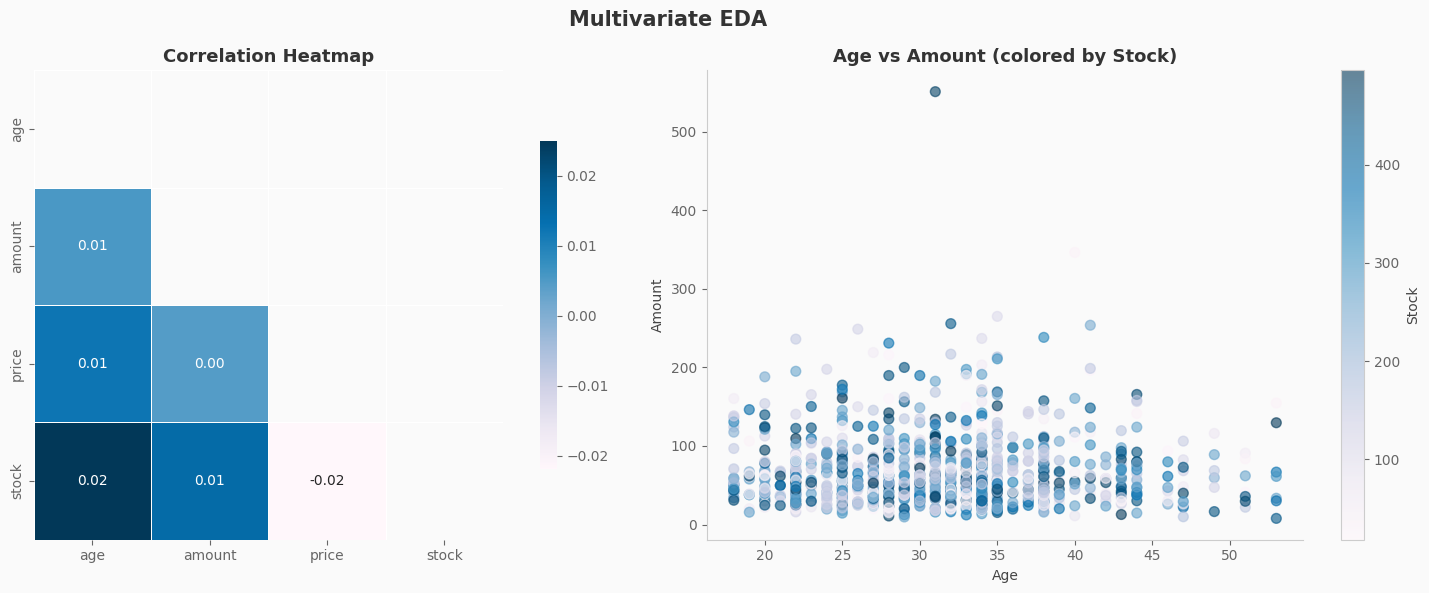

In [50]:
# Multivariate EDA: Correlation heatmaps and pairplots to explore interactions between multiple variables

numeric_df = df[["age","amount","price","stock"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation Heatmap
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="PuBu",
            ax=axes[0], square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.7})
axes[0].set_title("Correlation Heatmap", fontweight="bold", fontsize=13)

# Pairplot (manual with scatter matrix)
cols = ["age","amount","price"]
for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        if i == j:
            continue
axes[1].scatter(numeric_df["age"], numeric_df["amount"], c=numeric_df["stock"],
                cmap="PuBu", alpha=0.6, s=50)
axes[1].set_xlabel("Age"); axes[1].set_ylabel("Amount")
axes[1].set_title("Age vs Amount (colored by Stock)", fontweight="bold", fontsize=13)
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label("Stock")

plt.suptitle("Multivariate EDA", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_multivariate.png", dpi=120, bbox_inches="tight")
plt.show()

### 7b. Grouped Multivariate — Category × Gender × Amount

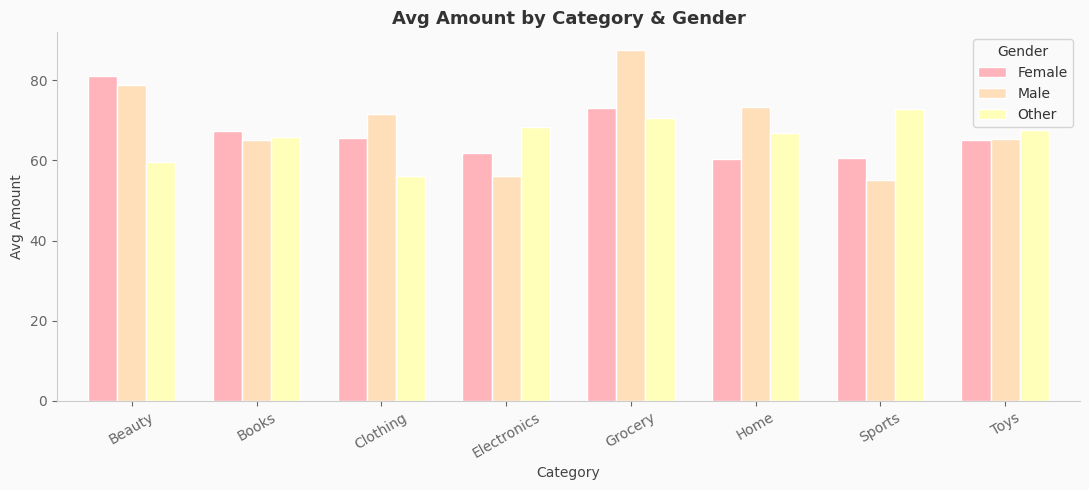

In [51]:
# Multivariate EDA: Pivot tables and grouped bar charts to explore interactions between categorical and numeric variables

pivot = df.pivot_table(index="category", columns="gender", values="amount", aggfunc="mean")
fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(kind="bar", ax=ax, color=PASTEL[:pivot.shape[1]], edgecolor="white", width=0.7)
ax.set_title("Avg Amount by Category & Gender", fontweight="bold", fontsize=13)
ax.set_xlabel("Category"); ax.set_ylabel("Avg Amount")
ax.legend(title="Gender")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("fig_multivariate2.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. 🩹 Missing Value Imputation

### 8a. SimpleImputer — Mean (numeric) & Most Frequent (categorical)

In [52]:
# Handling missing values with SimpleImputer

num_cols_imp = ["age", "amount", "price", "stock"]
cat_cols_imp = ["gender", "city", "payment_type"]

si_num = SimpleImputer(strategy="mean")
si_cat = SimpleImputer(strategy="most_frequent")

df_simple = df.copy()
df_simple[num_cols_imp] = si_num.fit_transform(df[num_cols_imp])
df_simple[cat_cols_imp] = si_cat.fit_transform(df[cat_cols_imp])

print("Missing after SimpleImputer:")
print(df_simple[[*num_cols_imp, *cat_cols_imp]].isnull().sum())
df_simple[[*num_cols_imp, *cat_cols_imp]].head()

Missing after SimpleImputer:
age             0
amount          0
price           0
stock           0
gender          0
city            0
payment_type    0
dtype: int64


,age,amount,price,stock,gender,city,payment_type
0,20.0,67.67,2286.25,251.0,Female,Patna,Wallet
1,35.0,76.44,1655.45,268.0,Other,Patna,UPI
2,35.0,104.57,1701.17,159.0,Other,Patna,Debit Card
3,23.0,102.75,4406.39,59.0,Female,Indore,Net Banking
4,28.0,23.89,393.65,58.0,Other,Kolkata,Net Banking


### 8b. KNN Imputer

In [53]:
# Handling missing values with KNNImputer - This code uses KNNImputer to fill in missing values in the numeric columns of the DataFrame. It creates a copy of the original DataFrame, applies KNNImputer to the specified numeric columns,
#  and then checks how many missing values remain after imputation. Finally, it displays descriptive statistics for the imputed numeric columns.

knn_imp = KNNImputer(n_neighbors=5)
df_knn = df.copy()
df_knn[num_cols_imp] = knn_imp.fit_transform(df[num_cols_imp])
print("Missing after KNNImputer:")
print(df_knn[num_cols_imp].isnull().sum())
df_knn[num_cols_imp].describe()

Missing after KNNImputer:
age       0
amount    0
price     0
stock     0
dtype: int64


,age,amount,price,stock
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,31.279000,67.599040,2440.259140,232.893000
std,7.211183,45.411375,1257.318565,141.376989
min,18.000000,7.810000,128.310000,18.000000
25%,26.000000,37.745000,1636.955000,134.000000
50%,31.000000,56.390000,2390.820000,229.000000
75%,35.000000,82.935000,3416.650000,332.000000
max,53.000000,550.950000,4970.990000,496.000000


### 8c. MICE (IterativeImputer)

In [54]:
# Handling missing values with MICE - This code uses the IterativeImputer (MICE) to fill in missing values in the numeric columns of the DataFrame.
#  It creates a copy of the original DataFrame, applies MICE to the specified numeric columns,

mice_imp = IterativeImputer(max_iter=10, random_state=42)
df_mice = df.copy()
df_mice[num_cols_imp] = mice_imp.fit_transform(df[num_cols_imp])
print("Missing after MICE:")
print(df_mice[num_cols_imp].isnull().sum())
df_mice[num_cols_imp].head()

Missing after MICE:
age       0
amount    0
price     0
stock     0
dtype: int64


,age,amount,price,stock
0,20.0,67.67,2286.25,251.0
1,35.0,76.44,1655.45,268.0
2,35.0,104.57,1701.17,159.0
3,23.0,102.75,4406.39,59.0
4,28.0,23.89,393.65,58.0


### 8d. Missing Indicator

In [55]:
# Creating missing value indicators - This code uses the MissingIndicator from scikit-learn to create binary indicator columns for each numeric column that has missing values. It fits the indicator on the original DataFrame's numeric columns and transforms it to get the indicator matrix.
#  Then, it creates a new DataFrame with these indicators, naming the columns based on the original column names with a "_missing" suffix. Finally, it prints the shape of the indicators DataFrame and displays its head.

from sklearn.impute import MissingIndicator
mi = MissingIndicator(features="missing-only")
indicators = mi.fit_transform(df[num_cols_imp])
ind_df = pd.DataFrame(indicators, columns=[f"{c}_missing" for c in np.array(num_cols_imp)[mi.features_]])
print("Missing Indicators shape:", ind_df.shape)
ind_df.head()

Missing Indicators shape: (1000, 0)


""
0
1
2
3
4


### 8e. Random Sample Imputation

In [56]:
# Handling missing values with Random Sample Imputation - This code defines a function random_sample_impute that takes a DataFrame and a column name as input. It creates a copy of the DataFrame, identifies the missing values in the specified column, and 
# fills those missing values by randomly sampling from the non-missing values in the same column. The function returns the modified DataFrame with imputed values. Then, it applies this function to each numeric column in num_cols_imp and checks
#  how many missing values remain after imputation.

def random_sample_impute(df, col):
    s = df.copy()
    missing = s[col].isnull()
    s.loc[missing, col] = s[col].dropna().sample(missing.sum(), replace=True).values
    return s

df_random = df.copy()
for c in num_cols_imp:
    df_random = random_sample_impute(df_random, c)
print("Missing after Random Sample Imputation:")
print(df_random[num_cols_imp].isnull().sum())

Missing after Random Sample Imputation:
age       0
amount    0
price     0
stock     0
dtype: int64


### 8f. Imputation Comparison — Distribution Plot

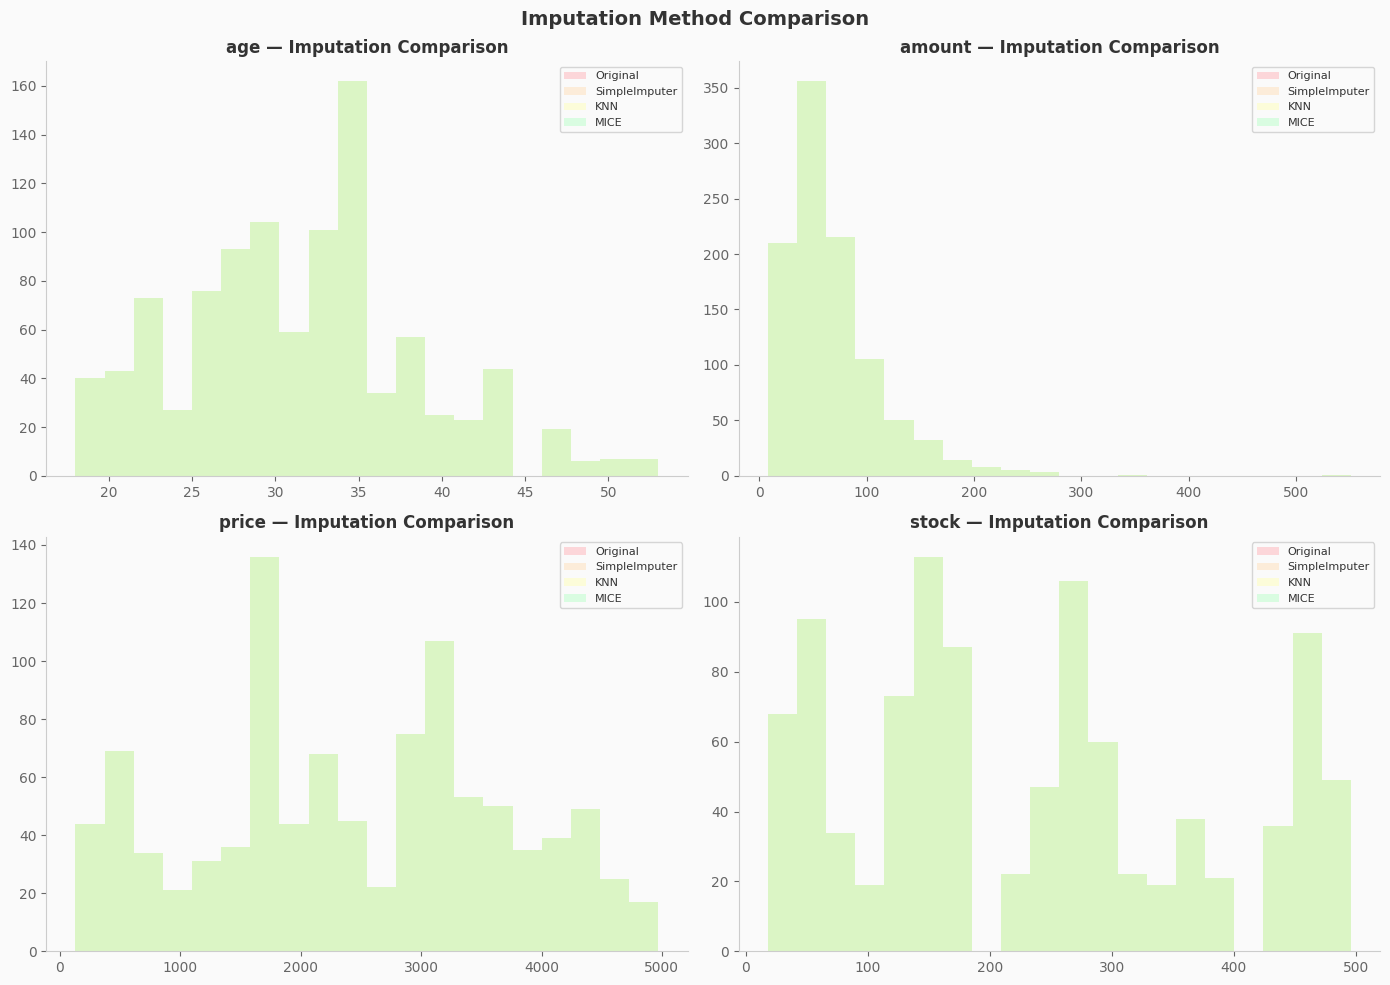

In [57]:
# Visual comparison of imputation methods - This code creates a 2x2 grid of histograms to visually compare the distributions of the original numeric columns with those imputed by SimpleImputer, KNNImputer, and MICE. 
# Each subplot shows the distribution of a specific numeric column across the different imputation methods, allowing for an easy visual assessment of how each method affects the data distribution.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols_imp):
    axes[i].hist(df[col].dropna(), bins=20, alpha=0.5, label="Original", color=PASTEL[0])
    axes[i].hist(df_simple[col], bins=20, alpha=0.5, label="SimpleImputer", color=PASTEL[1])
    axes[i].hist(df_knn[col], bins=20, alpha=0.5, label="KNN", color=PASTEL[2])
    axes[i].hist(df_mice[col], bins=20, alpha=0.5, label="MICE", color=PASTEL[3])
    axes[i].set_title(f"{col} — Imputation Comparison", fontweight="bold")
    axes[i].legend(fontsize=8)
plt.suptitle("Imputation Method Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_imputation.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. 🔎 Outlier Detection & Handling

### 9a. Z-Score Method

In [58]:
# Outlier detection with Z-Score - This code creates a copy of the DataFrame, calculates the Z-scores for the specified numeric columns,
# and identifies outliers based on a threshold of 3. It then prints the number of outliers detected and the total number of rows considered. Finally, 
# it creates a new DataFrame that excludes the outliers and prints the number of rows remaining after removal.

df_clean = df_simple.copy()
z_scores = np.abs(stats.zscore(df_clean[["amount", "price", "stock", "age"]].dropna()))
z_mask = (z_scores < 3).all(axis=1)
print(f"Z-Score: {(~z_mask).sum()} outliers detected out of {len(z_mask)}")
df_zscore = df_clean.dropna(subset=["amount","price","stock","age"]).reset_index(drop=True)
print(f"Rows after removal: {len(df_zscore)}")


numeric_cols = sales_df.select_dtypes(include=np.number).columns

outliers = (z_scores > 3).any(axis=1)

print("Outliers Count:", outliers.sum())

Z-Score: 22 outliers detected out of 1000
Rows after removal: 1000
Outliers Count: 22


### 9b. IQR Method

In [59]:
# IQR method for outlier detection - This code defines a function iqr_outliers that takes a DataFrame and a column name as input.
#  It calculates the first and third quartiles (Q1 and Q3) for the specified column, computes the interquartile range (IQR), and determines the lower and upper bounds for outliers. 
# The function returns a DataFrame that includes only the rows where the column values are within the calculated bounds. Then, it applies this function to each of the specified numeric columns and prints the number of outliers removed and the number of rows remaining after outlier removal.

def iqr_outliers(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

df_iqr = df_clean.copy()
before = len(df_iqr)
for col in ["amount", "price", "stock"]:
    df_iqr = iqr_outliers(df_iqr, col)
print(f"IQR: removed {before - len(df_iqr)} outliers, {len(df_iqr)} rows remaining")

IQR: removed 53 outliers, 947 rows remaining


### 9c. Percentile Method

In [60]:
# Percentile capping for outlier detection - This code defines a function percentile_cap that takes a DataFrame, a column name, and lower and upper percentile values as input.
#  It calculates the lower and upper bounds based on the specified percentiles for the given column and returns a DataFrame that includes only the rows where the column values are within these bounds.
#  Then, it applies this function to the "amount" and "price" columns of the cleaned DataFrame and prints the number of rows removed and remaining after applying the percentile capping method.

def percentile_cap(df, col, lower_p=1, upper_p=99):
    lo, hi = df[col].quantile(lower_p/100), df[col].quantile(upper_p/100)
    return df[(df[col] >= lo) & (df[col] <= hi)]

df_pct = df_clean.copy()
before = len(df_pct)
for col in ["amount", "price"]:
    df_pct = percentile_cap(df_pct, col)
print(f"Percentile: removed {before - len(df_pct)} rows, {len(df_pct)} rows remaining")

Percentile: removed 20 rows, 980 rows remaining


### 9d. Winsorization

In [61]:
# Winsorization for outlier handling - This code uses the winsorize function from scipy.stats.mstats to cap the values of the specified numeric columns at the 5th and 95th percentiles.
#  It creates a copy of the cleaned DataFrame, applies winsorization to the "amount", "price", and "stock" columns, filling any remaining missing values with the median before winsorizing. Finally, it prints descriptive statistics for the winsorized columns to show the effect of this outlier handling method.

from scipy.stats.mstats import winsorize
df_wins = df_clean.copy()
for col in ["amount", "price", "stock"]:
    df_wins[col] = winsorize(df_wins[col].fillna(df_wins[col].median()), limits=[0.05, 0.05])
print("After Winsorization:")
display(df_wins[["amount","price","stock"]].describe())

After Winsorization:


,amount,price,stock
count,1000.000000,1000.000000,1000.000000
mean,65.447590,2436.546630,232.362000
std,36.363538,1218.757098,138.739474
min,21.280000,393.650000,36.000000
25%,37.745000,1636.955000,134.000000
50%,56.390000,2390.820000,229.000000
75%,82.935000,3416.650000,332.000000
max,154.710000,4406.390000,467.000000


### 9e. Outlier Visualisation — Before vs After

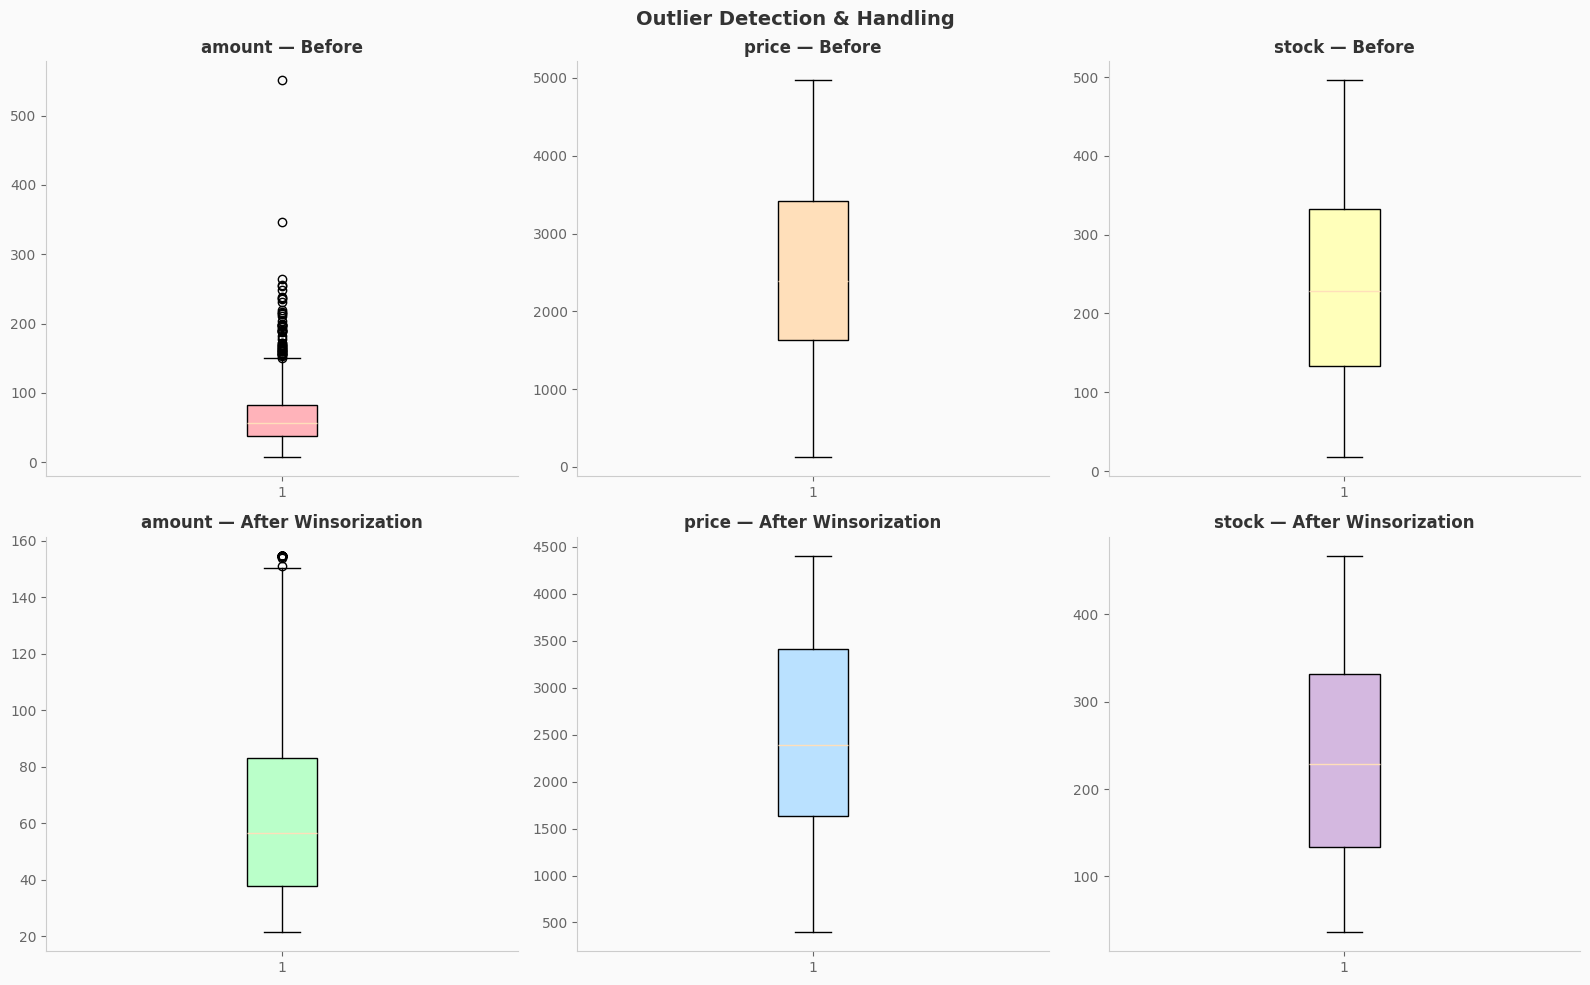

In [62]:
# Visual comparison of outlier handling methods - This code creates a 2x3 grid of boxplots to visually compare the distributions of the "amount", "price", and "stock"
#  columns before and after applying the winsorization method for outlier handling.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(["amount", "price", "stock"]):
    # Before
    axes[0, i].boxplot(df_clean[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor=PASTEL[i]))
    axes[0, i].set_title(f"{col} — Before", fontweight="bold")
    # After Winsorization
    axes[1, i].boxplot(df_wins[col], patch_artist=True,
                       boxprops=dict(facecolor=PASTEL[i+3]))
    axes[1, i].set_title(f"{col} — After Winsorization", fontweight="bold")

plt.suptitle("Outlier Detection & Handling", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_outliers.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. 📅 Handling Date Variables

In [63]:
# Feature engineering with date columns - This code creates new features from the "date" and "registration_date" columns in the DataFrame.
#  It converts these columns to datetime format, extracts components such as year, month, day, day of week, and quarter from the "date" column, and calculates the number of days since registration by finding the difference between the "date" and "registration_date". Finally, it prints the newly created date features for inspection.

df_feat = df_wins.copy()
df_feat["date"] = pd.to_datetime(df_feat["date"])
df_feat["registration_date"] = pd.to_datetime(df_feat["registration_date"])

df_feat["txn_year"]  = df_feat["date"].dt.year
df_feat["txn_month"] = df_feat["date"].dt.month
df_feat["txn_day"]   = df_feat["date"].dt.day
df_feat["txn_dayofweek"] = df_feat["date"].dt.dayofweek
df_feat["txn_quarter"] = df_feat["date"].dt.quarter

df_feat["reg_year"]  = df_feat["registration_date"].dt.year
df_feat["reg_month"] = df_feat["registration_date"].dt.month
df_feat["days_since_reg"] = (df_feat["date"] - df_feat["registration_date"]).dt.days

print("Date features created:")
print(df_feat[["date","txn_year","txn_month","txn_day","txn_dayofweek","txn_quarter","days_since_reg"]].head())

Date features created:
        date  txn_year  txn_month  txn_day  txn_dayofweek  txn_quarter  \
0 2023-02-12      2023          2       12              6            1   
1 2023-03-24      2023          3       24              4            1   
2 2025-08-21      2025          8       21              3            3   
3 2024-07-23      2024          7       23              1            3   
4 2025-10-04      2025         10        4              5            4   

   days_since_reg  
0             -31  
1            -496  
2             385  
3             383  
4            1087  


## 11. 🔀 Handling Mixed Variables

In [64]:
# Simulate a mixed column (e.g., "25kg", "30.5", "unknown")
df_feat["weight_mixed"] = np.random.choice(
    ["25kg", "30.5", "unknown", "40 kg", "55.2", "nan"], size=len(df_feat))

def extract_numeric(val):
    try:
        return float(str(val).replace("kg","").strip())
    except:
        return np.nan

df_feat["weight_clean"] = df_feat["weight_mixed"].apply(extract_numeric)
print("Mixed column sample:")
print(df_feat[["weight_mixed","weight_clean"]].head(10))
print(f"NaNs after extraction: {df_feat['weight_clean'].isnull().sum()}")

Mixed column sample:
  weight_mixed  weight_clean
0      unknown           NaN
1         55.2          55.2
2          nan           NaN
3         30.5          30.5
4         25kg          25.0
5         30.5          30.5
6      unknown           NaN
7          nan           NaN
8         55.2          55.2
9      unknown           NaN
NaNs after extraction: 322


## 12. 🧹 Complete Case Analysis

In [65]:
# Complete Case Analysis (CCA) - This code performs Complete Case Analysis by dropping all rows that contain any NaN values in the DataFrame. It prints the shape of the DataFrame before and after CCA, the number of rows removed,
#  and the percentage of data retained after dropping rows with missing values.

print("Shape before CCA:", df.shape)
df_cca = df.dropna()
print("Shape after CCA (drop all NaN rows):", df_cca.shape)
print(f"Rows removed: {len(df) - len(df_cca)}")
print(f"Data retained: {len(df_cca)/len(df)*100:.1f}%")

Shape before CCA: (1000, 14)
Shape after CCA (drop all NaN rows): (1000, 14)
Rows removed: 0
Data retained: 100.0%


## 13. 🏷️ Encoding Categorical Variables

### 13a. Label Encoding

In [66]:
# Label Encoding for categorical variables - This code creates a copy of the DataFrame and applies Label Encoding

df_enc = df_feat.copy()
le = LabelEncoder()
df_enc["gender_le"] = le.fit_transform(df_enc["gender"].astype(str))
df_enc["payment_le"] = le.fit_transform(df_enc["payment_type"].astype(str))
print("Label Encoding — gender:", dict(zip(le.classes_, le.transform(le.classes_))))
df_enc[["gender","gender_le","payment_type","payment_le"]].drop_duplicates().head(10)

Label Encoding — gender: {'Cash': np.int64(0), 'Credit Card': np.int64(1), 'Debit Card': np.int64(2), 'Net Banking': np.int64(3), 'UPI': np.int64(4), 'Wallet': np.int64(5)}


,gender,gender_le,payment_type,payment_le
0,Female,0,Wallet,5
1,Other,2,UPI,4
2,Other,2,Debit Card,2
3,Female,0,Net Banking,3
4,Other,2,Net Banking,3
5,Female,0,UPI,4
8,Male,1,Net Banking,3
12,Male,1,Cash,0
14,Male,1,Debit Card,2
16,Female,0,Credit Card,1


### 13b. One-Hot Encoding

In [67]:
# One-Hot Encoding for categorical variables - This code uses OneHotEncoder to create binary indicator columns for the "payment_type" and "category" categorical variables. 
# It fits the encoder on the specified columns, transforms the data to get the one-hot encoded features, and then creates a new DataFrame with these features.


ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_features = ohe.fit_transform(df_enc[["payment_type", "category"]])
ohe_cols = ohe.get_feature_names_out(["payment_type", "category"])
df_ohe = pd.DataFrame(ohe_features, columns=ohe_cols, index=df_enc.index)
df_enc = pd.concat([df_enc, df_ohe], axis=1)
print("OHE columns created:", ohe_cols.tolist())
df_enc[ohe_cols[:6]].head()

OHE columns created: ['payment_type_Cash', 'payment_type_Credit Card', 'payment_type_Debit Card', 'payment_type_Net Banking', 'payment_type_UPI', 'payment_type_Wallet', 'category_Beauty', 'category_Books', 'category_Clothing', 'category_Electronics', 'category_Grocery', 'category_Home', 'category_Sports', 'category_Toys']


,payment_type_Cash,payment_type_Credit Card,payment_type_Debit Card,payment_type_Net Banking,payment_type_UPI,payment_type_Wallet
0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0


### 13c. Ordinal Encoding

In [68]:
# Spending group bins and Ordinal Encoding - This code creates a new categorical feature "spend_group" by binning the "amount" 
# column into three groups: "Low", "Medium", and "High".
df_enc["spend_group"] = pd.cut(df_enc["amount"], bins=3, labels=["Low","Medium","High"])
oe = OrdinalEncoder(categories=[["Low","Medium","High"]])
df_enc["spend_group_encoded"] = oe.fit_transform(df_enc[["spend_group"]].astype(str))
print("Ordinal Encoding:")
df_enc[["amount","spend_group","spend_group_encoded"]].head(10)

Ordinal Encoding:


,amount,spend_group,spend_group_encoded
0,67.67,Medium,1.0
1,76.44,Medium,1.0
2,104.57,Medium,1.0
3,102.75,Medium,1.0
4,23.89,Low,0.0
5,31.10,Low,0.0
6,74.37,Medium,1.0
7,74.31,Medium,1.0
8,74.37,Medium,1.0
9,154.71,High,2.0


## 14. ⚖️ Feature Scaling

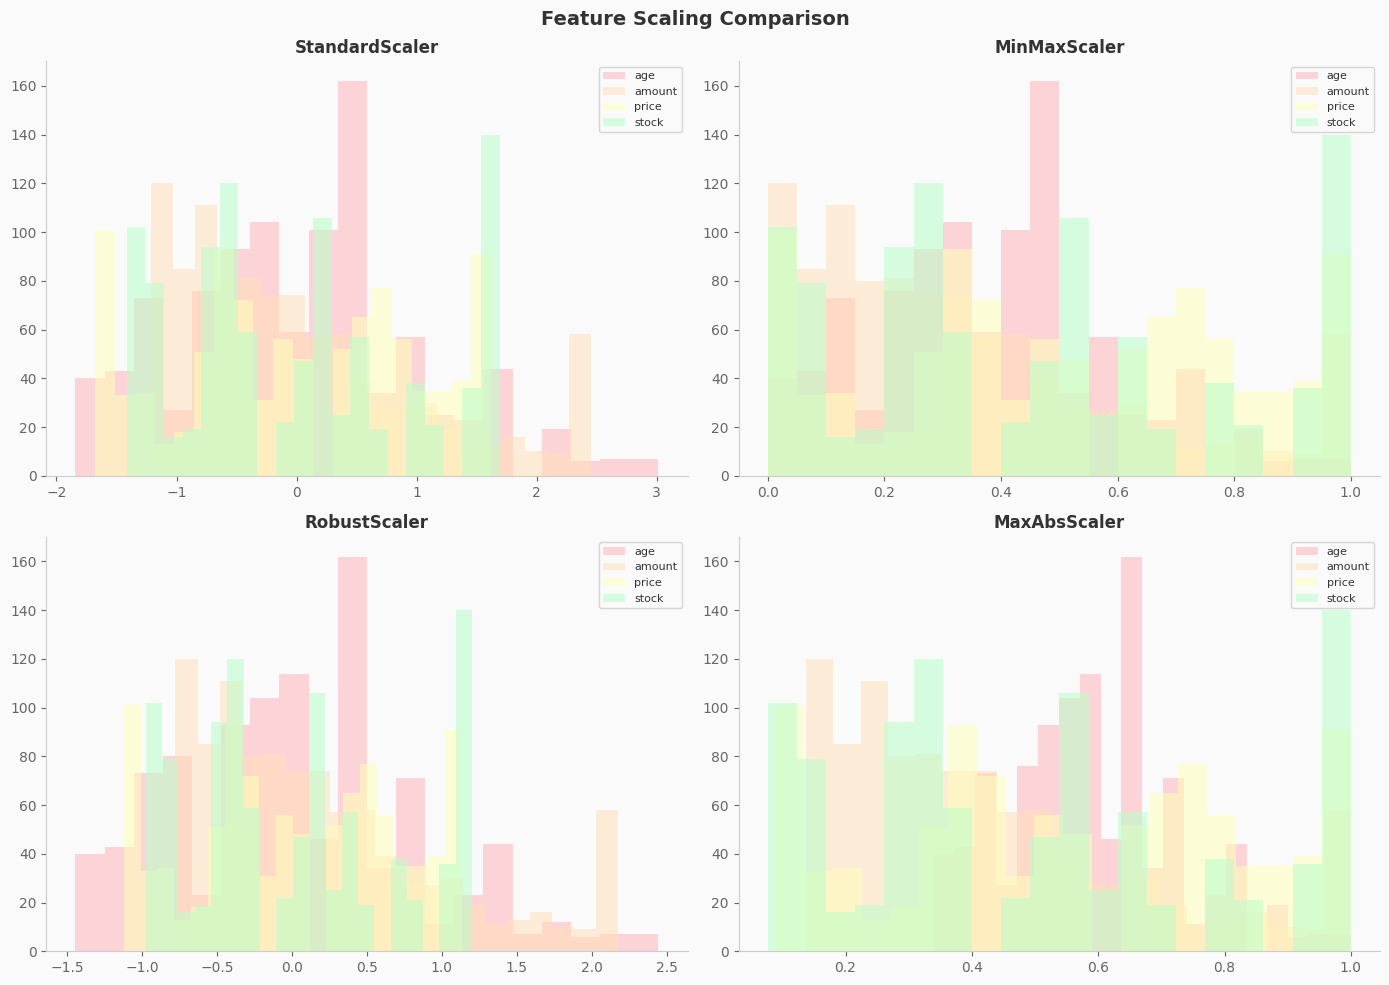

In [69]:
# Feature scaling with different scalers - This code applies various feature scaling techniques (StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler)
#  to the numeric columns of the DataFrame.


scale_cols = ["age", "amount", "price", "stock"]
X_num = df_enc[scale_cols].fillna(df_enc[scale_cols].median())

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler":   MinMaxScaler(),
    "RobustScaler":   RobustScaler(),
    "MaxAbsScaler":   MaxAbsScaler(),
}

scaled_results = {}
for name, scaler in scalers.items():
    scaled_results[name] = pd.DataFrame(scaler.fit_transform(X_num), columns=scale_cols)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, (name, res) in enumerate(scaled_results.items()):
    for j, col in enumerate(scale_cols):
        axes[i].hist(res[col], bins=20, alpha=0.55, label=col, color=PASTEL[j])
    axes[i].set_title(f"{name}", fontweight="bold")
    axes[i].legend(fontsize=8)
plt.suptitle("Feature Scaling Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_scaling.png", dpi=120, bbox_inches="tight")
plt.show()

## 15. 🏗️ Feature Construction

In [70]:
# Creating new features from existing ones - This code creates new features based on the existing columns in the DataFrame.
#  It calculates the average monthly spend per customer, purchase frequency, days since last purchase, and category-wise total expenditure per user.

df_feat2 = df_enc.copy()

# Average monthly spend per customer
df_feat2["txn_yearmonth"] = df_feat2["date"].dt.to_period("M")
monthly_spend = df_feat2.groupby(["user_id","txn_yearmonth"])["amount"].sum().reset_index()
avg_monthly = monthly_spend.groupby("user_id")["amount"].mean().rename("avg_monthly_spend")
df_feat2 = df_feat2.merge(avg_monthly, on="user_id", how="left")

# Purchase frequency per user
freq = df_feat2.groupby("user_id").size().rename("purchase_freq")
df_feat2 = df_feat2.merge(freq, on="user_id", how="left")

# Days since last purchase
last_txn = df_feat2.groupby("user_id")["date"].max().rename("last_txn_date")
df_feat2 = df_feat2.merge(last_txn, on="user_id", how="left")
df_feat2["days_since_last"] = (df_feat2["date"].max() - df_feat2["last_txn_date"]).dt.days

# Category-wise total expenditure per user
cat_spend = df_feat2.groupby(["user_id","category"])["amount"].sum().unstack(fill_value=0)
cat_spend.columns = [f"spend_{c.lower()}" for c in cat_spend.columns]
df_feat2 = df_feat2.merge(cat_spend, on="user_id", how="left")

new_feats = ["avg_monthly_spend","purchase_freq","days_since_last"] + list(cat_spend.columns)
print("New features created:", new_feats)
df_feat2[new_feats[:6]].head()

New features created: ['avg_monthly_spend', 'purchase_freq', 'days_since_last', 'spend_beauty', 'spend_books', 'spend_clothing', 'spend_electronics', 'spend_grocery', 'spend_home', 'spend_sports', 'spend_toys']


,avg_monthly_spend,purchase_freq,days_since_last,spend_beauty,spend_books,spend_clothing
0,71.731111,11,90,112.61,279.73,89.07
1,87.877143,7,72,97.72,186.11,0.00
2,87.877143,7,72,97.72,186.11,0.00
3,88.104000,5,370,204.44,0.00,0.00
4,40.737500,4,28,0.00,52.54,0.00


### 15b. Feature Construction Visualisation

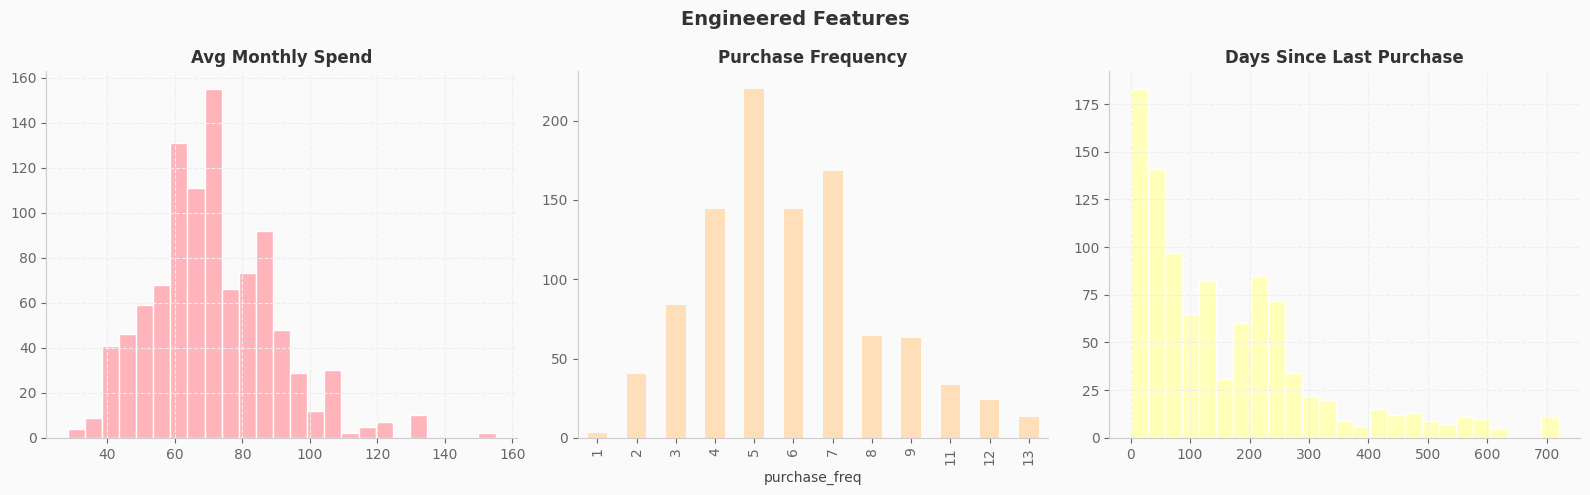

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_feat2["avg_monthly_spend"].hist(bins=25, ax=axes[0], color=PASTEL[0], edgecolor="white")
axes[0].set_title("Avg Monthly Spend", fontweight="bold")

df_feat2["purchase_freq"].value_counts().sort_index().head(20).plot(kind="bar", ax=axes[1], color=PASTEL[1])
axes[1].set_title("Purchase Frequency", fontweight="bold")

df_feat2["days_since_last"].hist(bins=25, ax=axes[2], color=PASTEL[2], edgecolor="white")
axes[2].set_title("Days Since Last Purchase", fontweight="bold")

plt.suptitle("Engineered Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_features.png", dpi=120, bbox_inches="tight")
plt.show()

## 16. 🔄 PowerTransformer & FunctionTransformer 

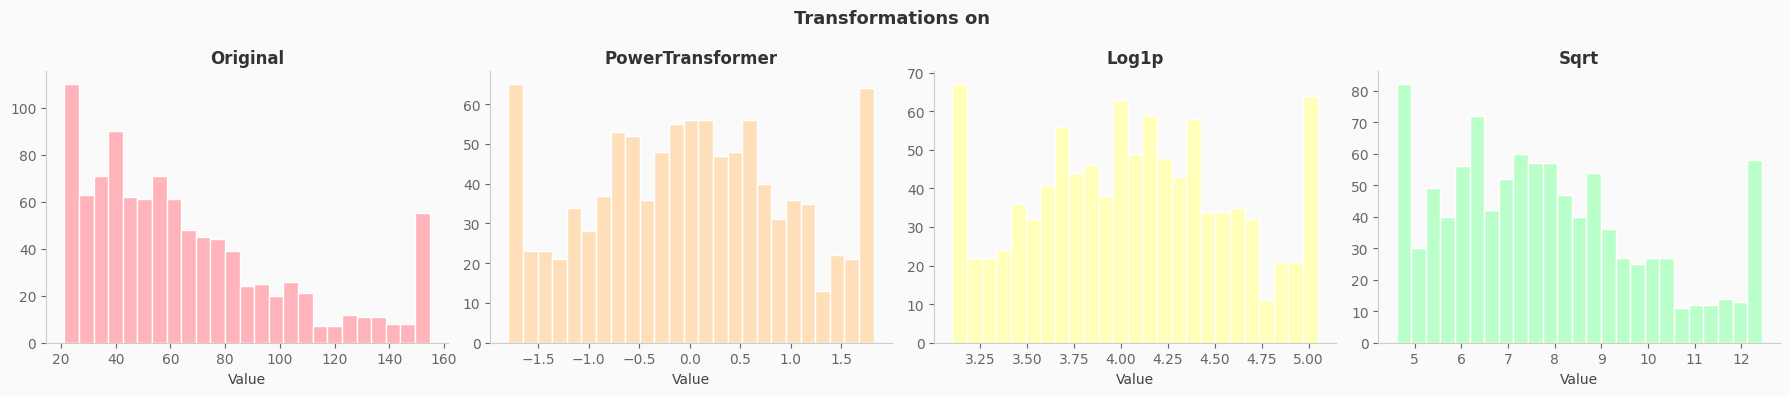

Original               Skewness: 0.9874
PowerTransformer       Skewness: 0.0073
Log1p                  Skewness: 0.0551
Sqrt                   Skewness: 0.5246


In [72]:
# Transformations for skewed data - This code applies different transformations (PowerTransformer, Log1p, Sqrt)
#  to the "amount" column of the DataFrame to address skewness in the data.

pt = PowerTransformer(method="yeo-johnson")
ft_log = FunctionTransformer(np.log1p)
ft_sqrt = FunctionTransformer(np.sqrt)

X_pos = np.abs(X_num) + 0.001  # ensure positive for sqrt/log

transformed = {
    "Original":          X_num["amount"],
    "PowerTransformer":  pd.Series(pt.fit_transform(X_num)[:, 1]),  # amount col
    "Log1p":             pd.Series(ft_log.fit_transform(X_pos)["amount"]),
    "Sqrt":              pd.Series(ft_sqrt.fit_transform(X_pos)["amount"]),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, (name, data) in enumerate(transformed.items()):
    axes[i].hist(data.dropna(), bins=25, color=PASTEL[i], edgecolor="white")
    axes[i].set_title(name, fontweight="bold")
    # QQ data on subtitle
    axes[i].set_xlabel("Value")

plt.suptitle("Transformations on ", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_transformers.png", dpi=120, bbox_inches="tight")
plt.show()

for name, data in transformed.items():
    skew = data.skew()
    print(f"{name:<22} Skewness: {skew:.4f}")

## 17. 🔧 ColumnTransformer — Full Pipeline

In [73]:
# Building a preprocessing pipeline with ColumnTransformer - This code defines a preprocessing pipeline using ColumnTransformer 
# to handle both numeric and categorical features.


numeric_features = ["age", "amount", "price","stock", "days_since_reg", "purchase_freq"]
categorical_features = ["gender", "payment_type", "category"]

df_pipe = df_feat2.copy()
for c in numeric_features:
    df_pipe[c] = pd.to_numeric(df_pipe[c], errors="coerce")
df_pipe = df_pipe.dropna(subset=numeric_features + categorical_features).reset_index(drop=True)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

X_transformed = preprocessor.fit_transform(df_pipe)
print("ColumnTransformer output shape:", X_transformed.shape)
print(f"Input: {len(numeric_features)} numeric + {len(categorical_features)} categorical features")
print(f"Output: {X_transformed.shape[1]} total features after encoding")
pd.DataFrame(X_transformed[:5, :6], columns=[f"feat_{i}" for i in range(6)])

ColumnTransformer output shape: (1000, 23)
Input: 6 numeric + 3 categorical features
Output: 23 total features after encoding


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5
0,-1.564881,0.061147,-0.123381,0.134405,-1.027273,2.137548
1,0.516262,0.302443,-0.641217,0.256998,-2.099746,0.444441
2,0.516262,1.076408,-0.603684,-0.529040,-0.067813,0.444441
3,-1.148652,1.026332,1.617081,-1.250176,-0.072425,-0.402113
4,-0.454938,-1.143409,-1.677052,-1.257387,1.551276,-0.825390


## 18. ✂️ Train-Test Split

Training set:   800 rows, 10 features
Test set:       200 rows,  10 features
Train/Test split: 80% / 20%


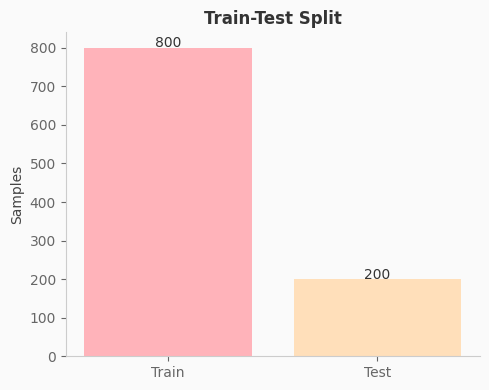

In [74]:
# Train-test split for modeling - This code prepares the data for modeling by defining the target variable and feature columns,
#  creating a copy of the preprocessed DataFrame, and ensuring that the necessary encoded columns are present.

target = "amount"
feature_cols = ["age", "price", "stock", "days_since_reg", "txn_month", "txn_dayofweek",
                "purchase_freq", "avg_monthly_spend", "gender_le", "payment_le"]

df_model = df_pipe.copy()
for c in ["gender_le","payment_le"]:
    if c not in df_model.columns:
        df_model[c] = 0

# Use available numeric features only
available_feats = [c for c in feature_cols if c in df_model.columns]
X = df_model[available_feats].fillna(0)
y = df_model[target].fillna(df_model[target].median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set:   {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Test set:       {X_test.shape[0]} rows,  {X_test.shape[1]} features")
print(f"Train/Test split: {len(X_train)/len(X)*100:.0f}% / {len(X_test)/len(X)*100:.0f}%")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Train", "Test"], [len(X_train), len(X_test)], color=[PASTEL[0], PASTEL[1]])
ax.set_title("Train-Test Split", fontweight="bold")
ax.set_ylabel("Samples")
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x()+p.get_width()/2, p.get_height()+1), ha="center")
plt.tight_layout()
plt.savefig("fig_split.png", dpi=120, bbox_inches="tight")
plt.show()

## 19. 📋 Pandas Profiling (Manual EDA Report)

In [75]:
# Custom function to display a pandas profiling-like summary - This code defines a function pandas_profile that takes a DataFrame and an optional name as input.
#  It prints a summary of the DataFrame, including its shape, memory usage, number of duplicate rows, and a column-wise summary 
# that shows the data type, number of missing values, number of unique values, and basic statistics for numeric columns or the most frequent value for categorical columns.

def pandas_profile(df, name="Dataset"):
    print(f"{'='*60}")
    print(f" EDA PROFILE: {name}")
    print(f"{'='*60}")
    print(f"Shape:         {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"Memory:        {df.memory_usage(deep=True).sum()/1024:.1f} KB")
    print(f"Duplicate rows:{df.duplicated().sum()}")
    print()
    print("--- Column Summary ---")
    for col in df.columns:
        dtype = df[col].dtype
        n_miss = df[col].isnull().sum()
        n_uniq = df[col].nunique()
        if pd.api.types.is_numeric_dtype(df[col]):
            print(f"{col:<30} {str(dtype):<12} missing={n_miss}  unique={n_uniq}  mean={df[col].mean():.2f}  std={df[col].std():.2f}")
        else:
            top = df[col].mode()[0] if not df[col].isnull().all() else "N/A"
            print(f"{col:<30} {str(dtype):<12} missing={n_miss}  unique={n_uniq}  top='{top}'")

profile_cols = ["age","amount","price","stock","gender","payment_type","category","city"]
pandas_profile(df_pipe[profile_cols], name="Merged & Cleaned Dataset")

 EDA PROFILE: Merged & Cleaned Dataset
Shape:         1000 rows × 8 columns
Memory:        247.5 KB
Duplicate rows:0

--- Column Summary ---
age                            float64      missing=0  unique=32  mean=31.28  std=7.21
amount                         float64      missing=0  unique=865  mean=65.45  std=36.36
price                          float64      missing=0  unique=46  mean=2436.55  std=1218.76
stock                          float64      missing=0  unique=40  mean=232.36  std=138.74
gender                         object       missing=0  unique=3  top='Male'
payment_type                   object       missing=0  unique=6  top='Wallet'
category                       object       missing=0  unique=8  top='Home'
city                           object       missing=0  unique=20  top='Kolkata'


## 20. 📊 Final Summary Report

In [76]:
print("="*65)
print("           FINAL DATA ENGINEERING SUMMARY REPORT")
print("="*65)
print(f"📁 SOURCE DATA")
print(f"   Users (CSV):        {users_df.shape[0]} rows × {users_df.shape[1]} cols")
print(f"   Sales (JSON):       {sales_df.shape[0]} rows × {sales_df.shape[1]} cols")
print(f"   Inventory (SQL):    {inv_df.shape[0]} rows × {inv_df.shape[1]} cols")
print(f"   Merged dataset:     {df.shape[0]} rows × {df.shape[1]} cols")

print(f"🔧 DATA CLEANING")
print(f"   Missing values introduced (simulation): ~10%")
print(f"   Imputation methods applied: SimpleImputer, KNNImputer, MICE, Random")
print(f"   Outlier methods: Z-Score, IQR, Percentile, Winsorization")
print(f"   Complete Case Analysis: {len(df_cca)} rows retained ({len(df_cca)/len(df)*100:.1f}%)")

print(f"🏷️  ENCODING")
print(f"   Label Encoding: gender, payment_type")
print(f"   One-Hot Encoding: payment_type ({sum('payment_type' in c for c in ohe_cols)} cols), category ({sum('category' in c for c in ohe_cols)} cols)")
print(f"   Ordinal Encoding: spend_group (Low/Medium/High)")

print(f"📐 FEATURE ENGINEERING")
print(f"   Date features created: txn_year, txn_month, txn_day, txn_dayofweek, txn_quarter, days_since_reg")
print(f"   Constructed features: avg_monthly_spend, purchase_freq, days_since_last")
print(f"   Category spend columns: {sum('spend_' in c for c in df_feat2.columns)}")

print(f"⚖️  SCALING")
print(f"   Methods compared: StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler")

print(f"🤖 MODELLING PREP")
print(f"   ColumnTransformer output: {X_transformed.shape[1]} features")
print(f"   Train samples: {len(X_train)} | Test samples: {len(X_test)}")
print(f"   Train-Test Ratio: 80% / 20%")
print()
print("="*65)
print("           ALL TASKS COMPLETED SUCCESSFULLY ✅")
print("="*65)

           FINAL DATA ENGINEERING SUMMARY REPORT
📁 SOURCE DATA
   Users (CSV):        290 rows × 6 cols
   Sales (JSON):       1000 rows × 6 cols
   Inventory (SQL):    50 rows × 5 cols
   Merged dataset:     1000 rows × 14 cols
🔧 DATA CLEANING
   Missing values introduced (simulation): ~10%
   Imputation methods applied: SimpleImputer, KNNImputer, MICE, Random
   Outlier methods: Z-Score, IQR, Percentile, Winsorization
   Complete Case Analysis: 1000 rows retained (100.0%)
🏷️  ENCODING
   Label Encoding: gender, payment_type
   One-Hot Encoding: payment_type (6 cols), category (8 cols)
   Ordinal Encoding: spend_group (Low/Medium/High)
📐 FEATURE ENGINEERING
   Date features created: txn_year, txn_month, txn_day, txn_dayofweek, txn_quarter, days_since_reg
   Constructed features: avg_monthly_spend, purchase_freq, days_since_last
   Category spend columns: 10
⚖️  SCALING
   Methods compared: StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
🤖 MODELLING PREP
   ColumnTransformer o

## 21. 💾 Export Final Cleaned Dataset

In [ ]:
# Exporting the final cleaned and engineered dataset to CSV - This code selects a subset of columns from the preprocessed DataFrame that are relevant for analysis or modeling, and exports this subset to a CSV file named "final_cleaned_dataset.csv".
#  It also prints a confirmation message with the shape of the exported DataFrame and displays the first few rows of the exported data.

export_cols = ["transaction_id","user_id","product_id","amount",
              "payment_type","date","name","age","gender","city",
              "registration_date","category","price","stock"]

export_df = df_pipe[[c for c in export_cols if c in df_pipe.columns]]
export_df.to_csv("final_cleaned_dataset.csv", index=False)
print(f"Saved: final_cleaned_dataset.csv — {export_df.shape[0]} rows × {export_df.shape[1]} cols")
export_df.head()

Saved: final_cleaned_dataset.csv — 1000 rows × 14 cols


,transaction_id,user_id,product_id,amount,payment_type,date,name,age,gender,city,registration_date,category,price,stock
0,T000001,U0024,P015,67.67,Wallet,2023-02-12,Aarohi Kapoor,20.0,Female,Patna,2023-03-15,Books,2286.25,251.0
1,T000002,U0196,P044,76.44,UPI,2023-03-24,Kabir Kulkarni,35.0,Other,Patna,2024-08-01,Beauty,1655.45,268.0
2,T000003,U0196,P049,104.57,Debit Card,2025-08-21,Kabir Kulkarni,35.0,Other,Patna,2024-08-01,Home,1701.17,159.0
3,T000004,U0133,P042,102.75,Net Banking,2024-07-23,Diya Singh,23.0,Female,Indore,2023-07-06,Home,4406.39,59.0
4,T000005,U0047,P038,23.89,Net Banking,2025-10-04,Anaya Gupta,28.0,Other,Kolkata,2022-10-13,Home,393.65,58.0
